In [23]:
from __future__ import annotations

import random
import math
import numpy as np
import simpy

import matplotlib.cm as cm
import numpy as np

import matplotlib.pyplot as plt

QPUs = ["qpu0", "qpu1", "qpu2"]


class Task:
    def __init__(self, id:str, targets=QPUs, parent=None, duration=0, end=0, priority=0):
        self.id = id
        self.parent = parent
        self.duration = duration
        self.targets = targets
        self.priority = priority
        self.end = end
        self.skip_count = 0
        self.initial_kwargs = {
            'id': id,
            'targets': targets,
            'parent': parent,
            'duration': duration,
            'end': end,
            'priority': priority,
            'skip_count': 0,
        }

    def update(self, end, aging=0):
        if end > self.end:
            if self.end > 0:
                self.skip_count += 1
            self.end = end
            if self.parent:
                # Dont age the parent!
                self.parent.update(end, aging=0)
        if aging > 0:
            self.priority += aging
            
    def reset(self):
        for key, value in self.initial_kwargs.items():
            setattr(self, key, value)
        return self
        

class Queues:
    def __init__(self, env):
        self.q = {qpu: [] for qpu in QPUs}
        self.end = {qpu: 0 for qpu in QPUs}
        self.sym_queue = {qpu: simpy.Store(env) for qpu in QPUs}

    def get_shortest_q(self, targets):
        # sort targets before choosing shortest queue
        sorted_targets = sorted(targets)
        return min(sorted_targets, key=self.end.get)
    
    def load_to_simpy_queue(self):
        for qpu, sub_tasks in self.q.items():
            for sub_task in sub_tasks:
                self.sym_queue[qpu].put(sub_task)


def create_tasks(num_tasks, max_sub_tasks, max_duration):
    tasks = []
    for i in range(num_tasks):
        new_id = str(i) + '.' + str(0)
        targets = random.sample(QPUs, random.randint(1, len(QPUs)))
        priority = random.randint(1, 3)
        duration = random.randint(1, max_duration)
        new_task = Task(new_id, targets=targets, duration=duration, priority=priority)

        # random number of sub_tasks
        num_sub_tasks = random.randint(1, max_sub_tasks)

        if num_sub_tasks == 1: # only the parent task
            tasks.append(new_task)
        else:
            for j in range(0, num_sub_tasks):
                sub_id = str(i) + '.' + str(j+1)
                sub_duration = random.randint(1, max_duration)
                # random subset of parent targets
                sub_targets = random.sample(targets, random.randint(1, len(targets)))
                sub_task = Task(sub_id, targets=sub_targets, parent=new_task, duration=sub_duration, priority=priority)
                tasks.append(sub_task)
            
    return tasks


def distribute_equally(tasks, queues, scheduler, aging=0):
    # group tasks by parent
    tasks_by_parent = {}
    for task in tasks:
        parent = task.parent if task.parent else task
        tasks_by_parent[parent] = tasks_by_parent.get(task.parent, []) + [task]

    # sort subtasks by duration
    duration_sorted_tasks = {}
    for parent, sub_tasks in tasks_by_parent.items():
        duration_sorted_tasks[parent] = sorted(sub_tasks, key=lambda x: x.duration, reverse=True)


    # priorty sort task groups by priority 1-3
    priority_sorted_parents = {
        3: [parent for parent in duration_sorted_tasks.keys() if parent.priority == 3],
        2: [parent for parent in duration_sorted_tasks.keys() if parent.priority == 2],
        1: [parent for parent in duration_sorted_tasks.keys() if parent.priority == 1],
    }


    # distribute tasks according to priority
    for sorted_parents in priority_sorted_parents.values():
        # random order for within each priority
        for parent in sorted_parents:
            # decreasing duration subtask order
            for task in duration_sorted_tasks[parent]:
                q_name = queues.get_shortest_q(task.targets)
                shortest_q = queues.q[q_name]
                scheduler(task, shortest_q, aging)
                #print_queue(queues)
                queues.end[q_name] += task.duration
    return


def skipping_scheduler(new_task, queue, aging=0):
    new_parent = new_task.parent if new_task.parent else new_task

    if queue == []:
        queue.append(new_task)
        new_task.update(new_task.duration, aging=0)

    else:
        i, predicted_end = 0, 0
        for last_task in reversed(queue):
            predicted_end = last_task.end + new_task.duration # if skipping last_task
            last_parent = last_task.parent if last_task.parent else last_task
            
            if new_task.priority > math.floor(last_task.priority): # must skip lower priority task
                last_task.update(predicted_end, aging)
                i += 1 # skip last_task
                continue
            
            elif new_task.priority == last_task.priority: # can skip same priority task
                if predicted_end < last_parent.end:  # can skip in line (wo delaying other task)
                    if new_parent.end < last_parent.end:  # should skip in line (for overall speedup)
                        last_task.update(predicted_end, aging)
                        i += 1 # skip last_task
                        continue
            else: 
                break

        queue.insert(len(queue) - i, new_task)
        new_task.update(predicted_end, aging=0)


def fifo_scheduler(new_task, queue, aging=0):

    if queue == []:
        queue.append(new_task)
        new_task.update(new_task.duration, aging=0)

    else:
        i, predicted_end = 0, 0
        for last_task in reversed(queue):
            predicted_end = last_task.end + new_task.duration # if skipping last_task
            
            if new_task.priority > math.floor(last_task.priority): # must skip lower priority task
                last_task.update(predicted_end, aging)
                i += 1 # skip last_task
                continue
            else: 
                break
        
        queue.insert(len(queue) - i, new_task)
        new_task.update(predicted_end, aging=0)



def print_queue(queue, start=0, end=None):
    # enumerate distinct tasks
    for qpu, tasks in reversed(queue.q.items()):
        durations = str([task.id for task in tasks for _ in range(task.duration)][start:end])
        print(f'"{qpu}": {"".join(durations)}')
    print("---------------------------------")

In [24]:
def get_shortest_q(self, targets):
    # sort targets before choosing shortest queue
    sorted_targets = sorted(targets)
    return min(sorted_targets, key=self.end.get)

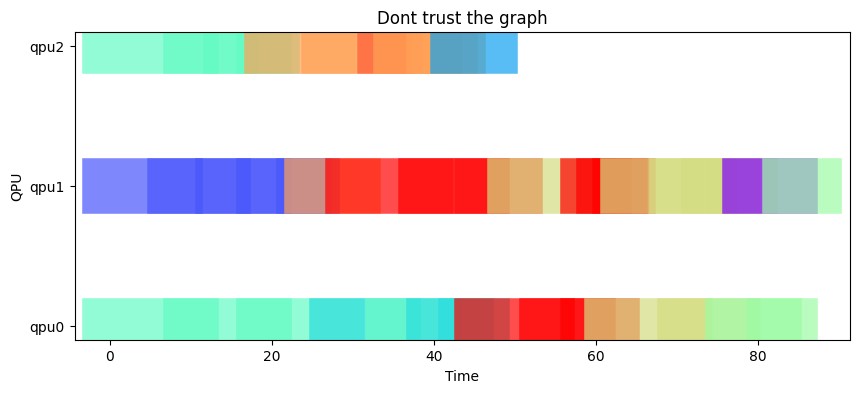

"qpu2": ['3.7', '3.7', '3.7', '3.7', '3.7', '3.7', '3.7', '3.7', '3.7', '3.7', '3.6', '3.6', '3.6', '3.6', '3.6', '3.2', '3.2', '3.2', '3.2', '3.5', '4.2', '4.2', '4.2', '4.2', '4.2', '4.2', '4.2', '4.3', '4.3', '4.3', '4.3', '4.3', '4.3', '4.3', '8.0', '8.0', '4.6', '4.6', '4.6', '4.6', '4.1', '4.1', '4.4', '2.0', '2.0', '2.0', '2.0']
"qpu1": ['1.2', '1.2', '1.2', '1.2', '1.2', '1.2', '1.2', '1.2', '1.4', '1.4', '1.4', '1.4', '1.4', '1.4', '1.1', '1.1', '1.1', '1.1', '1.1', '1.5', '1.5', '1.5', '1.5', '1.5', '1.3', '4.5', '4.5', '4.5', '4.5', '4.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.5', '0.2', '0.2', '0.2', '0.2', '0.2', '0.2', '0.2', '0.1', '0.1', '0.1', '0.1', '5.1', '5.1', '5.1', '5.1', '5.1', '5.1', '5.1', '5.1', '5.1', '0.6', '0.6', '0.8', '0.8', '0.7', '5.5', '5.5', '5.5', '5.5', '5.5', '5.5', '5.7', '5.7', '5.7', '5.7', '5.3', '5.3', '5.3', '5.2', '5.2', '7.0', '7.0', '7.0', '7.0', '7.0', '6.1', '6.1', '6.1']
"qpu0": ['3.3', '3.3', '3.3', '3.3', '3.3', 

In [25]:
def computer(env, queue, results, qpu):
    while True:
        # Get the next sub_task from the queue
        task = yield queue.get()

        # Record the start time
        start = env.now

        # Process the sub_task
        yield env.timeout(task.duration)

        # Record the end time
        end = env.now

        # Store the results
        j_id = task.id.split('.')[0]
        results.append((j_id, start, end, qpu))

# Create a SimPy environment
env = simpy.Environment()

# Create a Queues object
queues = Queues(env)

num_tasks, max_sub_tasks, max_duration = 10, 10, 10
tasks = create_tasks(num_tasks, max_sub_tasks, max_duration)

# Distribute tasks evenly among queues
distribute_equally(tasks, queues, skipping_scheduler, aging=0)

# Load sub_tasks into the SimPy queues
queues.load_to_simpy_queue()


# Create a list to store the results
results = []

# Start the computer processes
for qpu in QPUs:
    env.process(computer(env, queues.sym_queue[qpu], results, qpu))

# Run the simulation
env.run()

# Get unique sub_task_ids and assign a unique color to each
sub_task_ids = list(set([sub_task_id for sub_task_id, _, _, _ in results]))
colors = cm.rainbow(np.linspace(0, 1, len(sub_task_ids)))
color_map = dict(zip(sub_task_ids, colors))

# Plot the results
plt.figure(figsize=(10, 4))
for sub_task_id, start, end, qpu in results:
    plt.plot([start, end], [QPUs.index(qpu), QPUs.index(qpu)], color=color_map[sub_task_id], label=f'sub_task {sub_task_id}', linewidth=40,
             alpha=0.7)
plt.xlabel('Time')
plt.ylabel('QPU')
plt.title('Dont trust the graph')
plt.yticks(range(len(QPUs)), QPUs)
plt.show()

print_queue(queues)

# Variable: num_sub_tasks, max_duration

Average End Difference: 0.09524619836595856
Positive instances:  74 out of 90  =  82.22222222222221 %


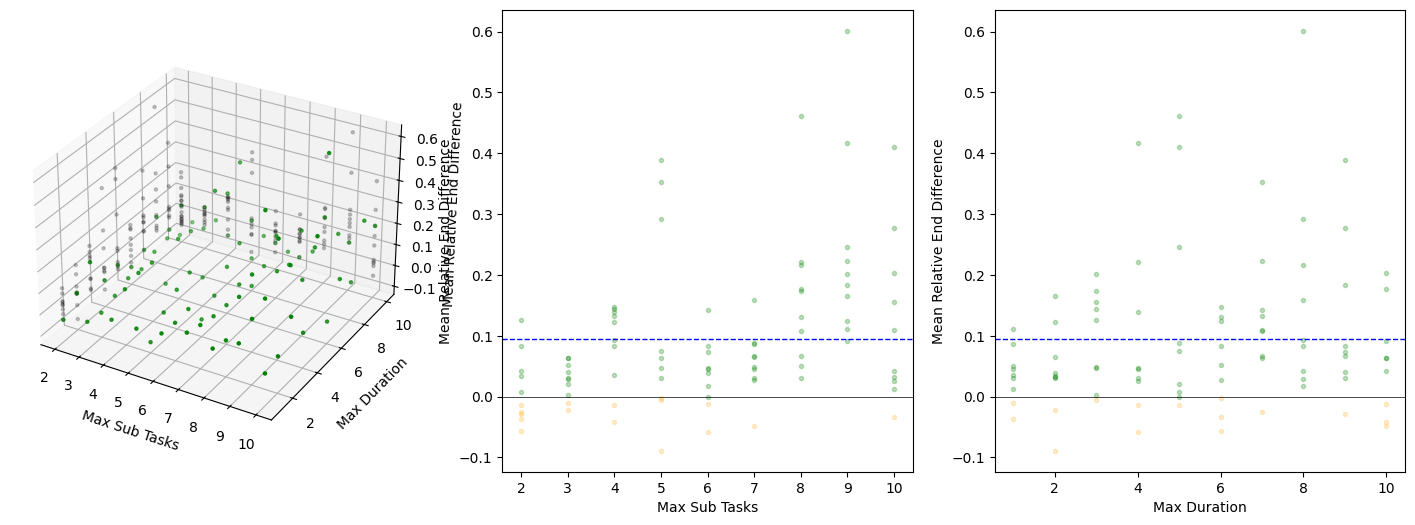

In [59]:
from IPython import display
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

max_diff = 0

def get_task_start(task_id, results):
    start_time = len(results)
    for sub_task_id, start, end, qpu in results:
        if sub_task_id == task_id:
            start_time = start if start < start_time else start_time
    return start_time

def get_task_end(task_id, results):
    end_time = 0
    for sub_task_id, start, end, qpu in results:
        if sub_task_id == task_id:
            end_time = end if end > end_time else end_time
    return end_time

num_batches = 4
aging_val = 0.
i, x, y, z = 0, [], [], []
for num_tasks in range(100, 101):
    for max_sub_tasks in range(2, 11): # 1 == only parent task
         for max_duration in range(1, 11):
            # Create random tasks
            tasks = create_tasks(num_tasks, max_sub_tasks, max_duration)

            queues, start_dicts, end_dicts, durations = [], [], [], []
            for scheduler in [skipping_scheduler, fifo_scheduler]:
                random.seed(1)
                
                # Create a SimPy environment
                env = simpy.Environment()

                # Create a Queues object
                queues.append(Queues(env))
                
                # Split tasks into batches, every parent tas
                batch, batches = [], []
                for task in tasks:
                    if batch != []:
                        id = task.id.split('.')[0]
                        last_id = batch[-1].id.split('.')[0]
                        if id != last_id:
                            if random.random() < 1/num_batches:
                                batches.append(batch)
                                batch = [task]
                                continue
                    
                    batch.append(task)
                batches.append(batch)
                            

                # Distribute tasks evenly among queues
                for batch in batches:
                    distribute_equally(batch, queues[-1], scheduler, aging=aging_val)


                # Load sub_tasks into the SimPy queues
                queues[-1].load_to_simpy_queue()

                # Create a list to store the results
                results = []

                # Start the computer processes
                for qpu in QPUs:
                    env.process(computer(env, queues[-1].sym_queue[qpu], results, qpu))

                # Run the simulation
                env.run()
       
                start_dicts.append({ #  Get start times for each parent task
                    task.id.split('.')[0]: 
                        get_task_start(task.id.split('.')[0], results) for task in tasks
                })
                end_dicts.append({ #  Get end times for each parent task
                    task.id.split('.')[0]: 
                        get_task_end(task.id.split('.')[0], results) for task in tasks
                })
                durations.append([ # Calculate the duration of each parent task
                    end_dicts[-1][id] - start_dicts[-1][id] for id in start_dicts[-1].keys()
                ])

                #print("Max Skip Count: ", max([task.skip_count for task in tasks]))
                tasks = [task.reset() for task in tasks]

            skipping_start_dict, fifo_start_dict = start_dicts[0], start_dicts[1]
            skipping_end_dict, fifo_end_dict = end_dicts[0], end_dicts[1]
            skipping_duration, fifo_duration = np.array(durations[0]), np.array(durations[1])

            # Calculate the difference in end times -> this is the time saved by skipping
            end_diff = np.array([fifo_end_dict[id] - skipping_end_dict[id] for id in skipping_end_dict.keys()])
            rel_end_diff = end_diff / fifo_duration
            mean_end_diff = np.mean(rel_end_diff)

            # Calculate the difference in durations -> could be negative
            rel_diff = (fifo_duration - skipping_duration) / fifo_duration
            mean_diff = np.mean(rel_diff)
            max_diff = max(rel_diff)
            
            # Update the plot
            
            x.append(max_sub_tasks)
            y.append(max_duration)
            z.append(mean_end_diff)

            #if mean_end_diff < 0.:
                #print(f"Max Sub Tasks: {max_sub_tasks}, Max Duration: {max_duration}, Mean Relative End Difference: {mean_end_diff}")

fig = plt.figure(figsize=(18, 6))

# 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_xlabel('Max Sub Tasks')
ax1.set_ylabel('Max Duration')
ax1.set_zlabel('Mean Relative End Difference')
# ... (your 3D plot code here) ...

print(f"Average End Difference: {np.mean(z)}")
# Plot shadows on the planes
ax1.scatter(x, y, z, c='green', marker='.')  # Shadow on the x-y plane
ax1.scatter(x, max(y), z, c='black', marker='.', alpha=0.2)  # Shadow on the x-z plane
ax1.scatter(min(x), y, z, c='black', marker='.', alpha=0.2)  # Shadow on the y-z plane

# Create masks for z > 0 and z <= 0
x = np.array(x)
y = np.array(y)
z = np.array(z)

mask_positive = z > 0
mask_negative_or_zero = z <= 0
print("Positive instances: ", len(z[mask_positive]), "out of", len(z), " = ", len(z[mask_positive]) / len(z) * 100, "%")

# Shadow on the x-z plane
ax2 = fig.add_subplot(132)
ax2.scatter(x[mask_positive], z[mask_positive], c='green', marker='.', alpha=0.25)
ax2.scatter(x[mask_negative_or_zero], z[mask_negative_or_zero], c='orange', marker='.', alpha=0.2)
ax2.set_xlabel('Max Sub Tasks')
ax2.set_ylabel('Mean Relative End Difference')
# Horitzontal lines at z=0 and z=np.average(z)
ax2.axhline(0, color='black', lw=0.5, linestyle='-')
ax2.axhline(np.mean(z), color='blue', lw=1, linestyle='--')

# Shadow on the y-z plane
ax3 = fig.add_subplot(133)
ax3.scatter(y[mask_positive], z[mask_positive], c='green', marker='.', alpha=0.25)
ax3.scatter(y[mask_negative_or_zero], z[mask_negative_or_zero], c='orange', marker='.', alpha=0.2)
ax3.set_xlabel('Max Duration')
ax3.set_ylabel('Mean Relative End Difference')
# Horitzontal lines at z=0 and z=np.average(z)
ax3.axhline(0, color='black', lw=0.5, linestyle='-')
ax3.axhline(np.mean(z), color='blue', lw=1, linestyle='--')

plt.draw()  # Redraw the plot

Average End Difference: 0.2249533215187708


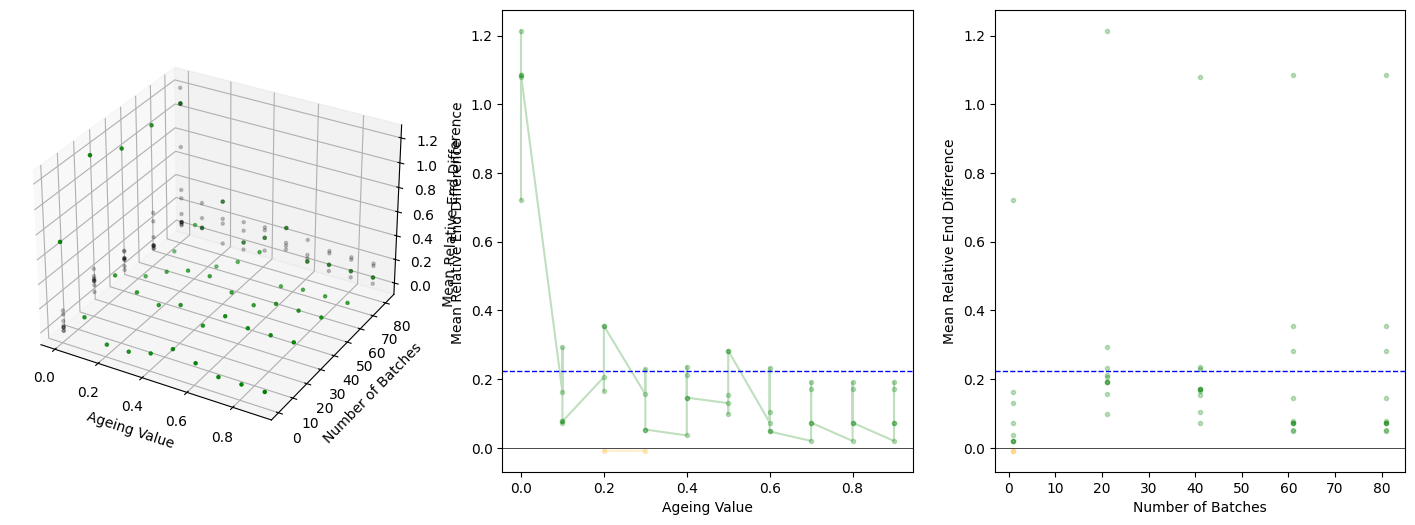

In [55]:
from IPython import display
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

max_diff = 0

def get_task_start(task_id, results):
    start_time = len(results)
    for sub_task_id, start, end, qpu in results:
        if sub_task_id == task_id:
            start_time = start if start < start_time else start_time
    return start_time

def get_task_end(task_id, results):
    end_time = 0
    for sub_task_id, start, end, qpu in results:
        if sub_task_id == task_id:
            end_time = end if end > end_time else end_time
    return end_time

max_sub_tasks = 10
max_duration = 10
i, x, y, z = 0, [], [], []
for num_tasks in range(100, 101):
    for aging_val in np.arange(0., 1., 0.1): # 1 == only parent task
         for num_batches in range(1, 100, 20):
            # Create random tasks
            tasks = create_tasks(num_tasks, max_sub_tasks, max_duration)

            queues, start_dicts, end_dicts, durations = [], [], [], []
            for scheduler in [skipping_scheduler, fifo_scheduler]:
                random.seed(1)
                
                # Create a SimPy environment
                env = simpy.Environment()

                # Create a Queues object
                queues.append(Queues(env))
                
                # Split tasks into batches, every parent tas
                batch, batches = [], []
                for task in tasks:
                    if batch != []:
                        id = task.id.split('.')[0]
                        last_id = batch[-1].id.split('.')[0]
                        if id != last_id:
                            if random.random() < 1/num_batches:
                                batches.append(batch)
                                batch = [task]
                                continue
                    
                    batch.append(task)
                batches.append(batch)
                            

                # Distribute tasks evenly among queues
                for batch in batches:
                    distribute_equally(batch, queues[-1], scheduler, aging=aging_val)


                # Load sub_tasks into the SimPy queues
                queues[-1].load_to_simpy_queue()

                # Create a list to store the results
                results = []

                # Start the computer processes
                for qpu in QPUs:
                    env.process(computer(env, queues[-1].sym_queue[qpu], results, qpu))

                # Run the simulation
                env.run()
       
                start_dicts.append({ #  Get start times for each parent task
                    task.id.split('.')[0]: 
                        get_task_start(task.id.split('.')[0], results) for task in tasks
                })
                end_dicts.append({ #  Get end times for each parent task
                    task.id.split('.')[0]: 
                        get_task_end(task.id.split('.')[0], results) for task in tasks
                })
                durations.append([ # Calculate the duration of each parent task
                    end_dicts[-1][id] - start_dicts[-1][id] for id in start_dicts[-1].keys()
                ])

                #print("Max Skip Count: ", max([task.skip_count for task in tasks]))
                tasks = [task.reset() for task in tasks]

            skipping_start_dict, fifo_start_dict = start_dicts[0], start_dicts[1]
            skipping_end_dict, fifo_end_dict = end_dicts[0], end_dicts[1]
            skipping_duration, fifo_duration = np.array(durations[0]), np.array(durations[1])

            # Calculate the difference in end times -> this is the time saved by skipping
            end_diff = np.array([fifo_end_dict[id] - skipping_end_dict[id] for id in skipping_end_dict.keys()])
            rel_end_diff = end_diff / fifo_duration
            mean_end_diff = np.mean(rel_end_diff)

            # Calculate the difference in durations -> could be negative
            rel_diff = (fifo_duration - skipping_duration) / fifo_duration
            mean_diff = np.mean(rel_diff)
            max_diff = max(rel_diff)
            
            # Update the plot
            
            x.append(aging_val)
            y.append(num_batches)
            z.append(mean_end_diff)

            #if mean_end_diff < 0.:
                #print(f"Max Sub Tasks: {max_sub_tasks}, Max Duration: {max_duration}, Mean Relative End Difference: {mean_end_diff}")

fig = plt.figure(figsize=(18, 6))

# 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_xlabel('Ageing Value')
ax1.set_ylabel('Number of Batches')
ax1.set_zlabel('Mean Relative End Difference')
# ... (your 3D plot code here) ...

print(f"Average End Difference: {np.mean(z)}")
# Plot shadows on the planes
ax1.scatter(x, y, z, c='green', marker='.')  # Shadow on the x-y plane
ax1.scatter(x, max(y), z, c='black', marker='.', alpha=0.2)  # Shadow on the x-z plane
ax1.scatter(min(x), y, z, c='black', marker='.', alpha=0.2)  # Shadow on the y-z plane

# Create masks for z > 0 and z <= 0
x = np.array(x)
x_mean = [np.mean(x) for _ in range(len(x))]
y = np.array(y)
z = np.array(z)

mask_positive = z > 0
mask_negative_or_zero = z <= 0

# Shadow on the x-z plane
ax2 = fig.add_subplot(132)
ax2.scatter(x[mask_positive], z[mask_positive], c='green', marker='.', alpha=0.25)
ax2.scatter(x[mask_negative_or_zero], z[mask_negative_or_zero], c='orange', marker='.', alpha=0.2)
ax2.set_xlabel('Ageing Value')
ax2.set_ylabel('Mean Relative End Difference')
# Horitzontal lines at z=0 and z=np.average(z)
ax2.axhline(0, color='black', lw=0.5, linestyle='-')
ax2.axhline(np.mean(z), color='blue', lw=1, linestyle='--')

# Shadow on the y-z plane
ax3 = fig.add_subplot(133)
ax3.scatter(y[mask_positive], z[mask_positive], c='green', marker='.', alpha=0.25)
ax3.scatter(y[mask_negative_or_zero], z[mask_negative_or_zero], c='orange', marker='.', alpha=0.2)
ax3.set_xlabel('Number of Batches')
ax3.set_ylabel('Mean Relative End Difference')
# Horitzontal lines at z=0 and z=np.average(z)
ax3.axhline(0, color='black', lw=0.5, linestyle='-')
ax3.axhline(np.mean(z), color='blue', lw=1, linestyle='--')

plt.draw()  # Redraw the plot